### Imports

In [1]:
import os
import gc
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import gc

from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score
)

### Load Data

In [2]:
BASE_PATH = r"C:\Users\mills\Desktop\Angione Lab\OC"

adata = sc.read_h5ad(os.path.join(BASE_PATH, "OC_adata_hvg.h5ad"))

adata_gene = sc.read_h5ad(os.path.join(BASE_PATH, "spatial", "OC_adata_hvg_graph_gene.h5ad"))
adata_cnn = sc.read_h5ad(os.path.join(BASE_PATH, "spatial", "OC_adata_hvg_with_cnn.h5ad"))
adata_multi = sc.read_h5ad(os.path.join(BASE_PATH, "spatial", "OC_adata_hvg_multimodal_graph.h5ad"))

### Attach Embeddings

In [3]:
adata.obsm["X_gene"] = adata_gene.obsm["X_graph_gene"]
adata.obsm["X_cnn"] = adata_cnn.obsm["X_cnn"]
adata.obsm["X_multi"] = adata_multi.obsm["X_graph_multimodal"]

### Leiden Clustering

In [4]:
modalities = {
    "Gene": "X_gene",
    "CNN": "X_cnn",
    "Multimodal": "X_multi"
}

for name, rep in modalities.items():
    print(f"Processing {name}...")

    sc.pp.neighbors(adata, use_rep=rep, key_added=f"neighbors_{name}")

    sc.tl.leiden(
        adata,
        neighbors_key=f"neighbors_{name}",
        resolution=1.0,
        key_added=f"leiden_{name}",
        flavor="igraph",
        n_iterations=2,
        directed=False
    )

Processing Gene...
Processing CNN...
Processing Multimodal...


### Memory cleanup

In [5]:
del adata_gene
del adata_cnn
del adata_multi

gc.collect()

746

### Metrics

In [6]:
results = []

for name, rep in modalities.items():
    X = adata.obsm[rep]
    labels = adata.obs[f"leiden_{name}"].astype(int)

    cluster_sizes = pd.Series(labels).value_counts()

    results.append({
        "Modality": name,
        "Silhouette": silhouette_score(X, labels),
        "Calinski-Harabasz": calinski_harabasz_score(X, labels),
        "Davies-Bouldin": davies_bouldin_score(X, labels),
        "Clusters": len(np.unique(labels)),
        "Mean Cluster Size": cluster_sizes.mean(),
        "Std Cluster Size": cluster_sizes.std()
    })

df_metrics = pd.DataFrame(results)
df_metrics.to_csv(os.path.join(BASE_PATH, "metrics.csv"), index=False)

df_metrics

,Modality,Silhouette,Calinski-Harabasz,Davies-Bouldin,Clusters,Mean Cluster Size,Std Cluster Size
0,Gene,0.023161,682.549468,3.190812,46,1371.130435,2194.396729
1,CNN,0.014524,455.545562,27.027784,255,247.341176,1082.606710
2,Multimodal,0.038381,957.916641,3.049178,41,1538.341463,2400.863049


### ARI

In [7]:
n_runs = 5
ari_results = []

for name, rep in modalities.items():
    runs = []

    for i in range(n_runs):
        sc.pp.neighbors(adata, use_rep=rep, key_added=f"tmp_{name}_{i}")

        sc.tl.leiden(
            adata,
            neighbors_key=f"tmp_{name}_{i}",
            key_added=f"tmp_leiden_{name}_{i}",
            random_state=i,
            flavor="igraph",
            n_iterations=2,
            directed=False
        )

        runs.append(adata.obs[f"tmp_leiden_{name}_{i}"].astype(int).values)

    ari_scores = [
        adjusted_rand_score(runs[i], runs[j])
        for i in range(n_runs)
        for j in range(i + 1, n_runs)
    ]

    ari_results.append({
        "Modality": name,
        "ARI": np.mean(ari_scores)
    })

df_ari = pd.DataFrame(ari_results)
df_ari.to_csv(os.path.join(BASE_PATH, "ari.csv"), index=False)

### Final table

In [8]:
df_final = df_metrics.merge(df_ari, on="Modality")
df_final.to_csv(os.path.join(BASE_PATH, "final_results.csv"), index=False)

df_final

,Modality,Silhouette,Calinski-Harabasz,Davies-Bouldin,Clusters,Mean Cluster Size,Std Cluster Size,ARI
0,Gene,0.023161,682.549468,3.190812,46,1371.130435,2194.396729,0.908891
1,CNN,0.014524,455.545562,27.027784,255,247.341176,1082.606710,0.553506
2,Multimodal,0.038381,957.916641,3.049178,41,1538.341463,2400.863049,0.931326


In [28]:
colors = {
    "Gene": "#4C72B0",        # blue
    "CNN": "#DD8452",         # orange
    "Multimodal": "#55A868"   # green
}

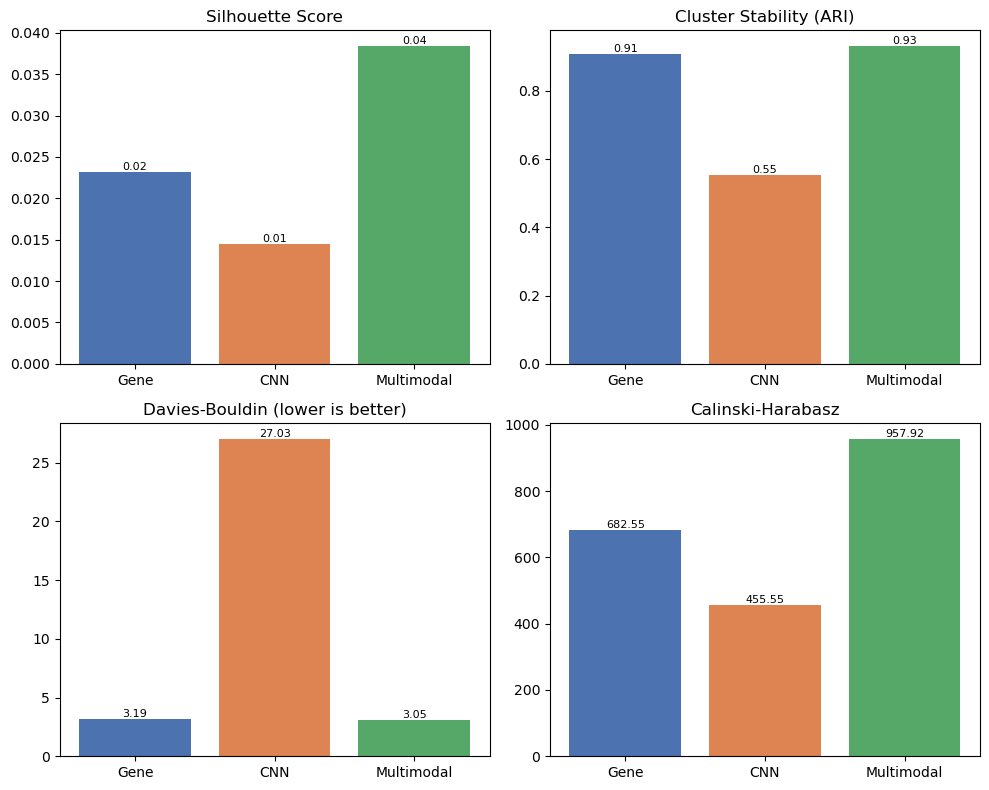

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

metrics = [
    ("Silhouette", axes[0,0], "Silhouette Score"),
    ("ARI", axes[0,1], "Cluster Stability (ARI)"),
    ("Davies-Bouldin", axes[1,0], "Davies-Bouldin (lower is better)"),
    ("Calinski-Harabasz", axes[1,1], "Calinski-Harabasz")
]

for metric, ax, title in metrics:

    bars = []

    for _, row in df_final.iterrows():
        bar = ax.bar(
            row["Modality"],
            row[metric],
            color=colors[row["Modality"]]
        )
        bars.append((bar, row[metric]))

    # Add value labels (2 decimal places)
    for bar, value in bars:
        ax.text(
            bar[0].get_x() + bar[0].get_width() / 2,
            bar[0].get_height(),
            f"{value:.2f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

    ax.set_title(title)
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()

plt.savefig(os.path.join(BASE_PATH, "metrics_colored_panel_decimal.pdf"), dpi=300)
plt.show()

### CNN plot

In [9]:
top_clusters = (
    adata.obs["leiden_CNN"]
    .value_counts()
    .head(15)
    .index
)

adata.obs["leiden_CNN_top"] = adata.obs["leiden_CNN"].where(
    adata.obs["leiden_CNN"].isin(top_clusters)
)

### Plots

In [10]:
colors = ["skyblue", "orange", "green"]

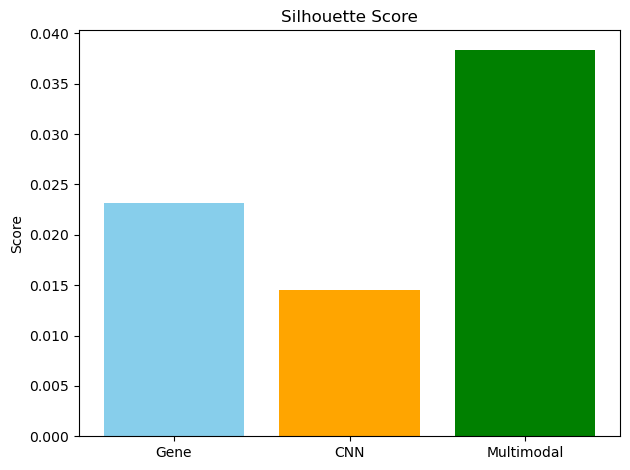

In [11]:
plt.figure()
plt.bar(df_final["Modality"], df_final["Silhouette"], color=colors)
plt.title("Silhouette Score")
plt.ylabel("Score")

plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, "silhouette.pdf"))
plt.show()

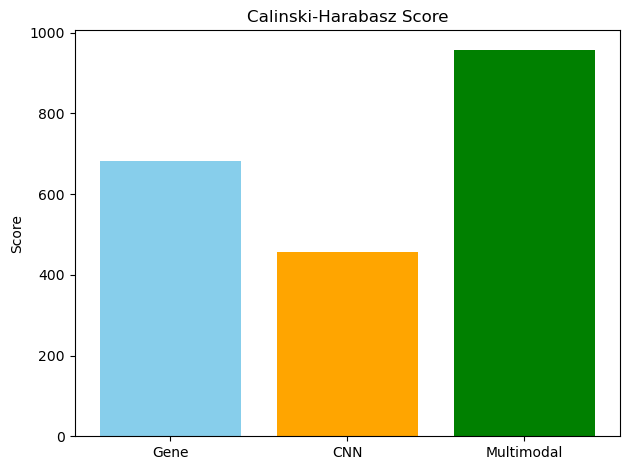

In [12]:
plt.figure()
plt.bar(df_final["Modality"], df_final["Calinski-Harabasz"], color=colors)
plt.title("Calinski-Harabasz Score")
plt.ylabel("Score")

plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, "calinski_harabasz.pdf"))
plt.show()

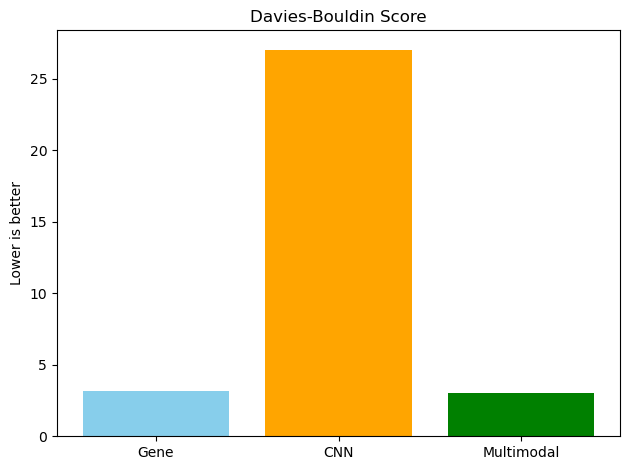

In [13]:
plt.figure()
plt.bar(df_final["Modality"], df_final["Davies-Bouldin"], color=colors)
plt.title("Davies-Bouldin Score")
plt.ylabel("Lower is better")

plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, "davies_bouldin.pdf"))
plt.show()

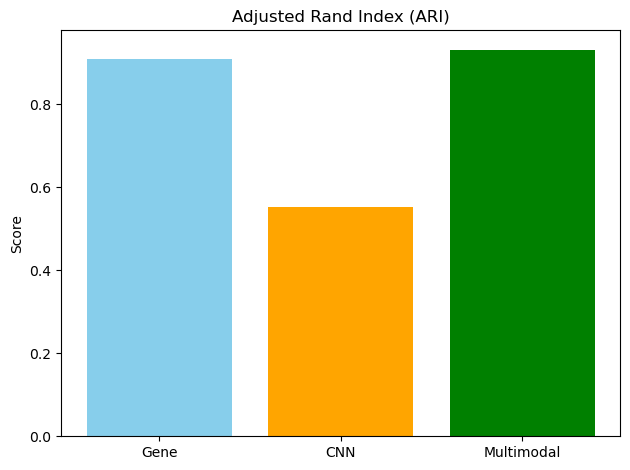

In [14]:
plt.figure()
plt.bar(df_final["Modality"], df_final["ARI"], color=colors)
plt.title("Adjusted Rand Index (ARI)")
plt.ylabel("Score")

plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, "ari.pdf"))
plt.show()

In [15]:
# sc.pl.umap(
#     adata,
#     color="leiden_CNN",
#     legend_loc=None,
#     show=False
# )

# plt.savefig(os.path.join(BASE_PATH, "cnn_umap_clean.pdf"))
# plt.close()

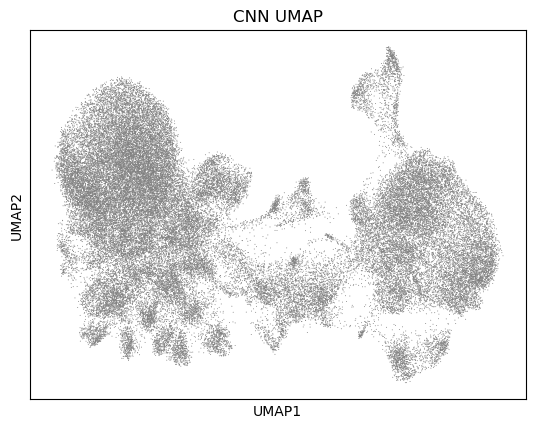

<Figure size 640x480 with 0 Axes>

In [16]:
sc.pl.umap(
    adata,
    color="leiden_CNN",
    legend_loc="none",
    title="CNN UMAP",
    show=True
)

plt.savefig(os.path.join(BASE_PATH, "cnn_umap_clean.pdf"), bbox_inches="tight")
plt.show()
plt.close()

In [17]:
# sc.pl.umap(
#     adata,
#     color="leiden_CNN_top",
#     legend_loc="right margin",
#     show=False
# )

# plt.savefig(os.path.join(BASE_PATH, "cnn_umap_top.pdf"))
# plt.close()

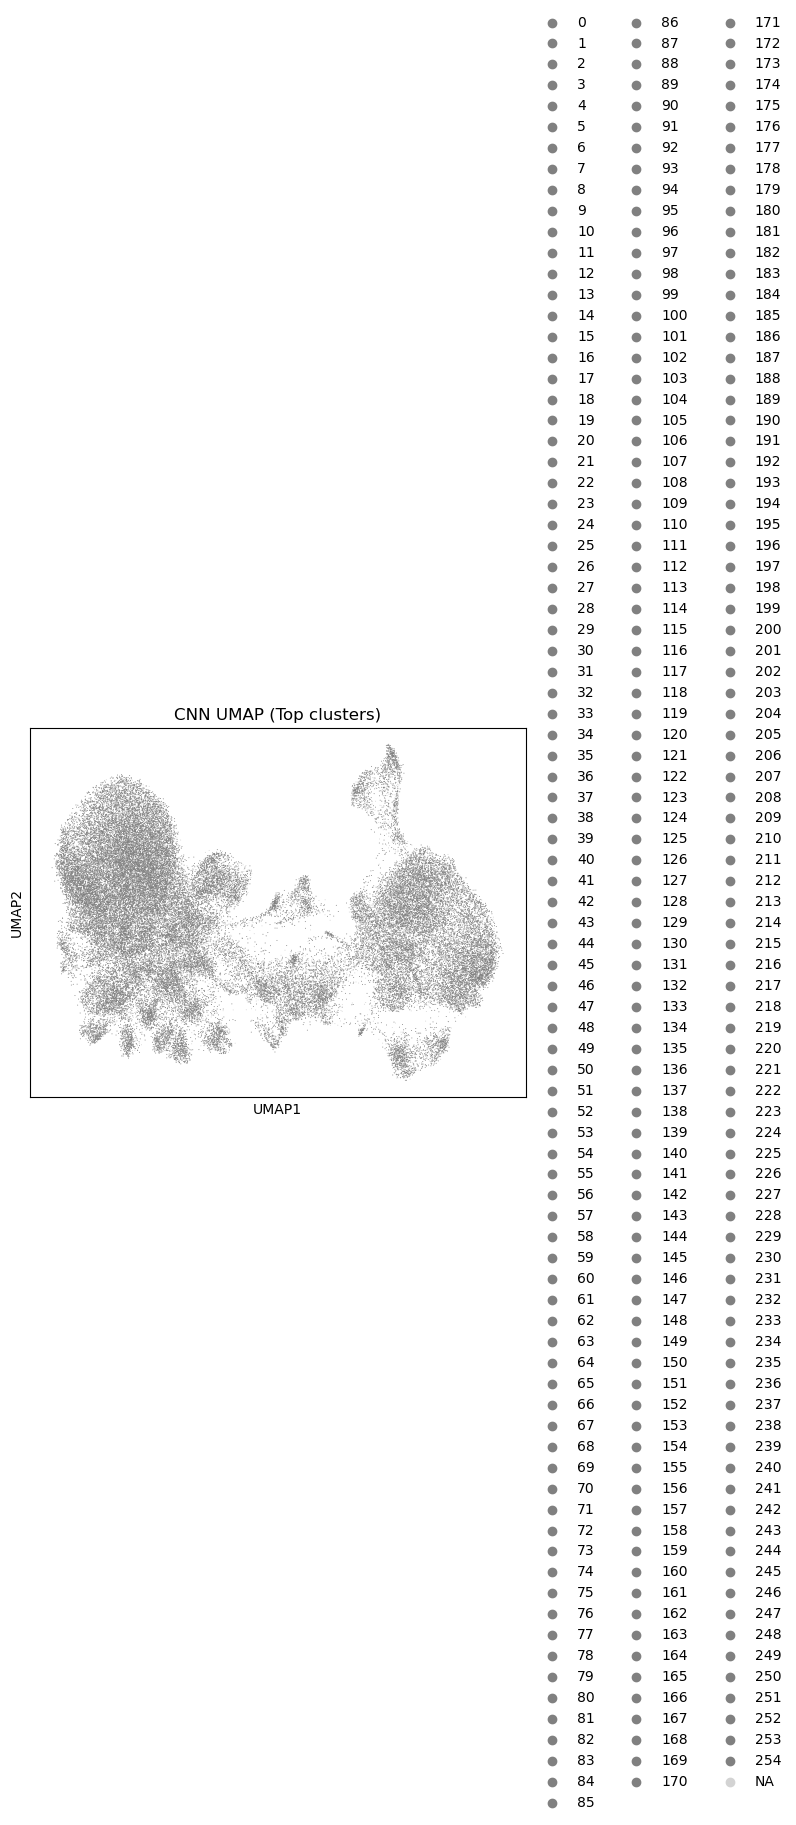

In [18]:
sc.pl.umap(
    adata,
    color="leiden_CNN_top",
    legend_loc="right margin",
    title="CNN UMAP (Top clusters)",
    show=False
)

plt.savefig(os.path.join(BASE_PATH, "cnn_umap_top.pdf"), bbox_inches="tight")
plt.show()
plt.close()

In [19]:
# for name in ["Gene", "Multimodal"]:
#     sc.pl.umap(
#         adata,
#         color=f"leiden_{name}",
#         legend_loc="right margin",
#         show=False
#     )

#     plt.savefig(os.path.join(BASE_PATH, f"{name}_umap.pdf"))
#     plt.close()

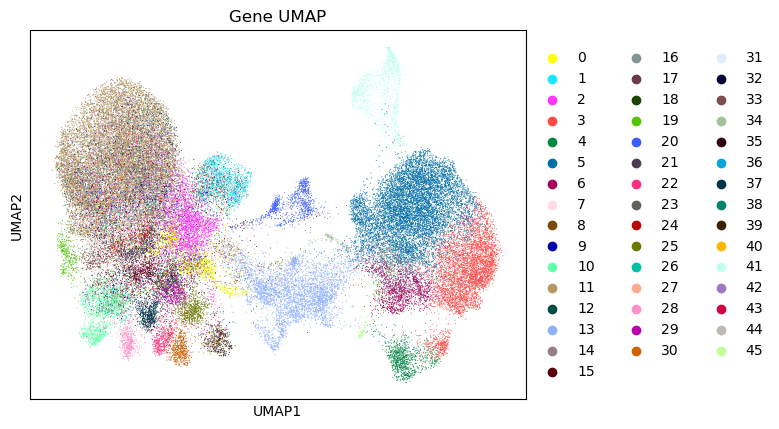

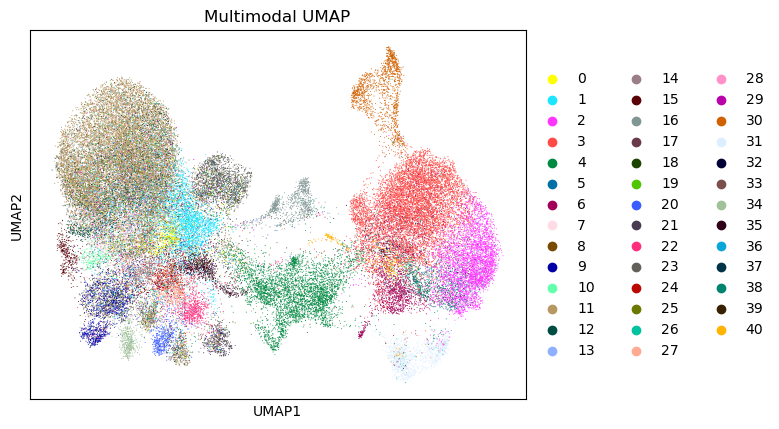

In [20]:
for name in ["Gene", "Multimodal"]:
    sc.pl.umap(
        adata,
        color=f"leiden_{name}",
        legend_loc="right margin",
        title=f"{name} UMAP",
        show=False
    )

    plt.savefig(os.path.join(BASE_PATH, f"{name}_umap.pdf"), bbox_inches="tight")
    plt.show()
    plt.close()

In [21]:
# for name in modalities:
#     sc.pl.scatter(
#         adata,
#         x="center_x",
#         y="center_y",
#         color=f"leiden_{name}",
#         legend_loc="none",   
#         show=False
#     )

#     plt.savefig(os.path.join(BASE_PATH, f"{name}_spatial.pdf"))
#     plt.close()

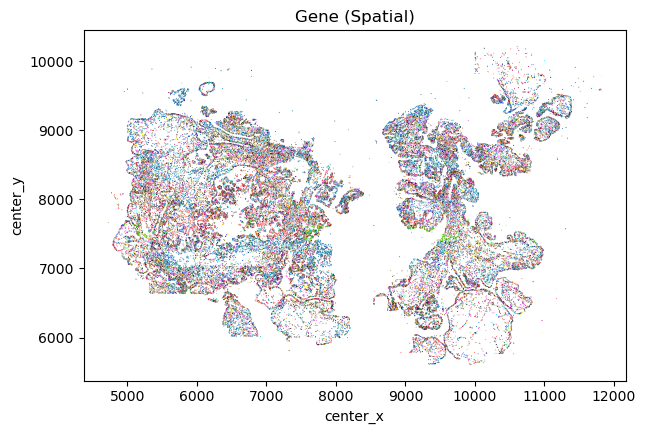

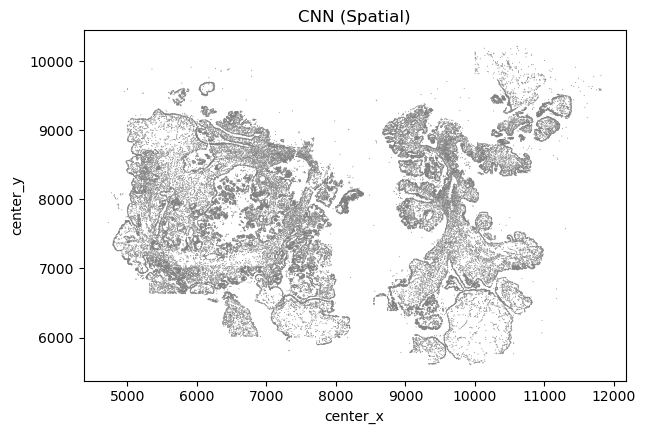

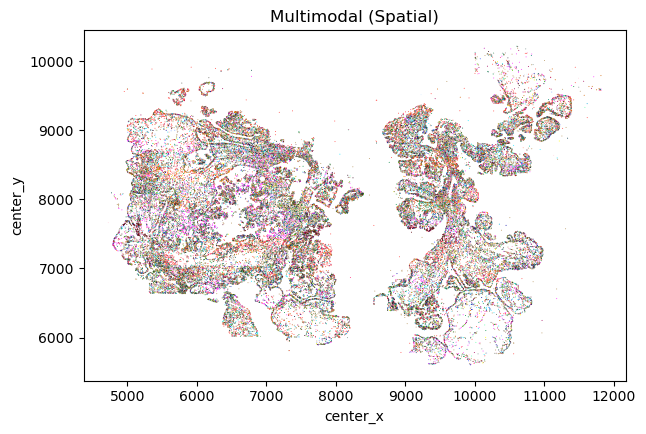

In [25]:
for name in modalities:
    sc.pl.scatter(
        adata,
        x="center_x",
        y="center_y",
        color=f"leiden_{name}",
        legend_loc="none",
        title=f"{name} (Spatial)",
        show=False
    )

    plt.savefig(os.path.join(BASE_PATH, f"{name}_spatial.pdf"), bbox_inches="tight")
    plt.show()
    plt.close()

Ablation Study

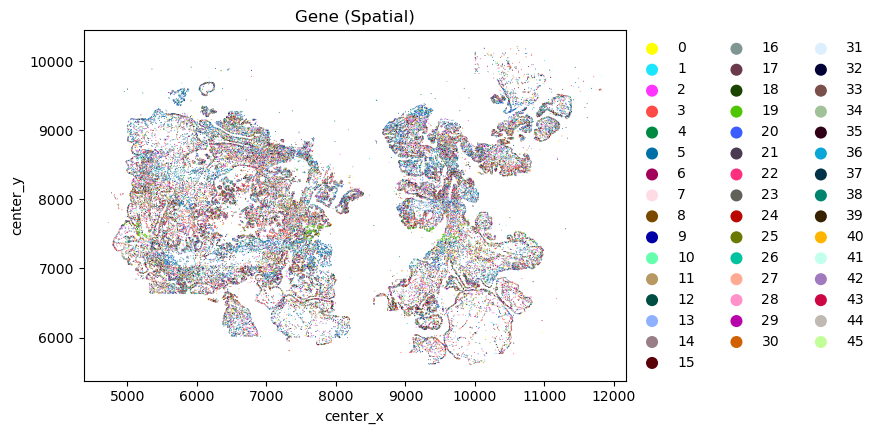

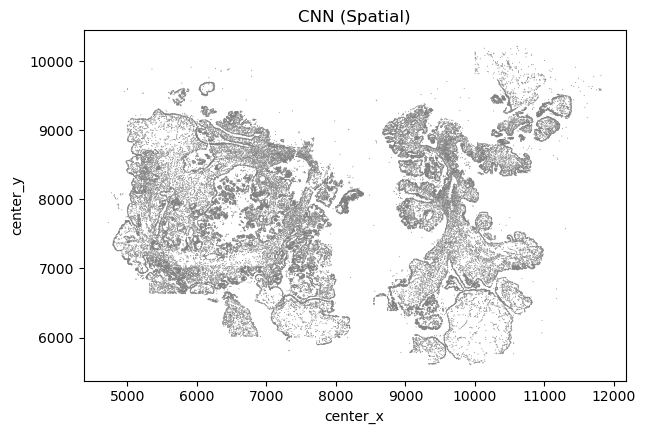

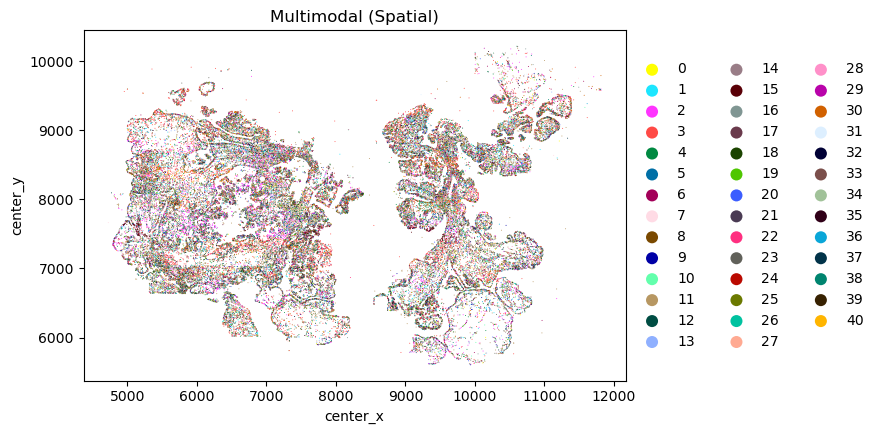

In [26]:
legend_map = {
    "Gene": "right margin",
    "Multimodal": "right margin",
    "CNN": "none"
}

for name in modalities:
    sc.pl.scatter(
        adata,
        x="center_x",
        y="center_y",
        color=f"leiden_{name}",
        legend_loc=legend_map[name],
        title=f"{name} (Spatial)",
        show=False
    )

    plt.savefig(os.path.join(BASE_PATH, f"{name}_spatial.pdf"), bbox_inches="tight")
    plt.show()
    plt.close()

In [24]:
adata.write_h5ad(os.path.join(BASE_PATH, "adata_with_clusters.h5ad"))